# Plot KITTI Odometry Inference Trajectory

This notebook loads `kitti_odom_inference.py` outputs, connects batch-local `camera_poses` into a full-sequence trajectory, optionally aligns that trajectory to KITTI odometry GT, and also plots a start-point-only estimate without scaling.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from mapanything.utils.kitti_odom_trajectory import (
    align_predicted_trajectory_start_point,
    align_predicted_trajectory_to_gt,
    camera_centers_from_poses,
    connect_batch_camera_poses,
    load_optional_kitti_gt_poses,
    load_sequence_results,
)

# RESULTS_PATH can point to either a single batch .npz file or the sequence results directory.
RESULTS_PATH = Path(
    "/home/kobayashi/dataset/kitti_odom/inference_outputs/mapanything/window_50_res_518/image_2/09"
    # "/home/kobayashi/dataset/kitti_odom/inference_outputs/da3_nested/window_100_long_side_728/image_2/09"
)
# Set DATASET_ROOT = None to skip GT loading and only plot the estimated trajectory.
DATASET_ROOT = Path("/home/kobayashi/dataset/kitti_odom/dataset")
ALIGN_TO_GT = True
FIGSIZE = (10, 8)
GT_COLOR = "tab:blue"
PRED_COLOR = "tab:orange"
PRED_START_ONLY_COLOR = "tab:green"


In [2]:
loaded_results = load_sequence_results(RESULTS_PATH)
batch_results = list(loaded_results.batch_results)
manifest = loaded_results.manifest or {}
first_batch = batch_results[0]

sequence_results_dir = loaded_results.sequence_results_dir
model_name = first_batch.model
sequence_id = first_batch.sequence
camera = first_batch.camera
window_size = manifest.get("config", {}).get(
    "window_size",
    first_batch.window_end - first_batch.window_start,
)
long_side_resolution = manifest.get("config", {}).get("long_side_resolution")
base_resolution = manifest.get("model_spec", {}).get("resolution")
resolution_label = (
    f"long_side={long_side_resolution}"
    if long_side_resolution is not None
    else f"base_res={base_resolution}"
)

connected_camera_poses, filled_mask, connected_frame_ids = connect_batch_camera_poses(
    batch_results
)
pred_traj_full = camera_centers_from_poses(connected_camera_poses)

if not filled_mask.any():
    raise RuntimeError("The connected trajectory is empty.")

first_valid_index = int(np.flatnonzero(filled_mask)[0])

for batch in batch_results:
    expected_anchor = connected_frame_ids[batch.window_start]
    if expected_anchor and expected_anchor != batch.frame_ids[0]:
        raise AssertionError(
            f"Frame id mismatch for {batch.path.name} at window_start={batch.window_start}: "
            f"expected {expected_anchor}, got {batch.frame_ids[0]}"
        )

summary = {
    "Results dir": str(sequence_results_dir),
    "Model": model_name,
    "Sequence ID": sequence_id,
    "Camera": camera,
    "Batch files": len(batch_results),
    "Window size": window_size,
    "Connected predicted frames": int(filled_mask.sum()),
    "First valid frame": first_valid_index,
    "Resolution label": resolution_label,
}


In [3]:
gt_poses = load_optional_kitti_gt_poses(DATASET_ROOT, sequence_id)
gt_traj_full = None
traj_to_plot = pred_traj_full.copy()
traj_similarity_aligned = None
traj_start_aligned = None
global_alignment_scale = None

if gt_poses is not None:
    gt_traj_full = camera_centers_from_poses(gt_poses)
    if len(pred_traj_full) > len(gt_traj_full):
        raise ValueError(
            f"Predicted trajectory has {len(pred_traj_full)} frames, but GT only has {len(gt_traj_full)}"
        )
    traj_start_aligned = align_predicted_trajectory_start_point(
        predicted_trajectory=pred_traj_full,
        gt_trajectory=gt_traj_full,
        filled_mask=filled_mask,
    )
    if ALIGN_TO_GT:
        traj_similarity_aligned, global_alignment_scale = align_predicted_trajectory_to_gt(
            predicted_trajectory=pred_traj_full,
            gt_trajectory=gt_traj_full,
            filled_mask=filled_mask,
        )
        traj_to_plot = traj_similarity_aligned
    else:
        traj_to_plot = traj_start_aligned

summary["GT available"] = gt_poses is not None
summary["Similarity aligned"] = traj_similarity_aligned is not None
summary["Start-point aligned"] = traj_start_aligned is not None
summary["Global alignment scale"] = global_alignment_scale

for key, value in summary.items():
    print(f"{key}: {value}")


Results dir: /home/kobayashi/dataset/kitti_odom/inference_outputs/da3_nested/window_100_long_side_728/image_2/09
Model: da3_nested
Sequence ID: 09
Camera: image_2
Batch files: 16
Window size: 100
Connected predicted frames: 1591
First valid frame: 0
Resolution label: long_side=728
GT available: True
Similarity aligned: True
Start-point aligned: True
Global alignment scale: 1.4082902883183506


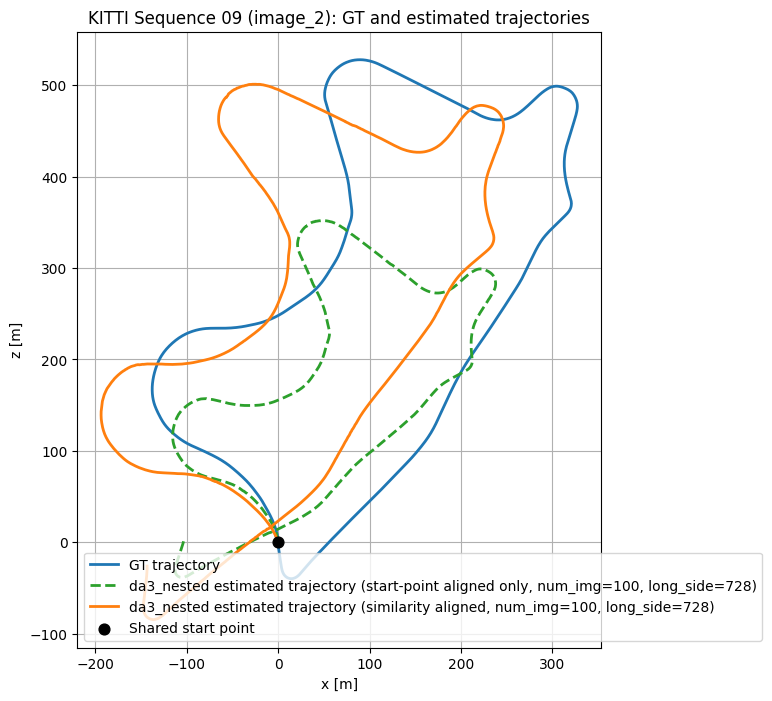

In [4]:
fig, ax = plt.subplots(figsize=FIGSIZE)

if gt_traj_full is not None:
    ax.plot(
        gt_traj_full[:, 0],
        gt_traj_full[:, 2],
        label="GT trajectory",
        linewidth=2,
        color=GT_COLOR,
    )

if traj_start_aligned is not None and traj_similarity_aligned is not None:
    start_only_label = (
        f"{model_name} estimated trajectory (start-point aligned only, num_img={window_size}, "
        f"{resolution_label})"
    )
    ax.plot(
        traj_start_aligned[filled_mask, 0],
        traj_start_aligned[filled_mask, 2],
        label=start_only_label,
        linewidth=2,
        linestyle="--",
        color=PRED_START_ONLY_COLOR,
    )

if traj_similarity_aligned is not None:
    pred_label = (
        f"{model_name} estimated trajectory (similarity aligned, num_img={window_size}, "
        f"{resolution_label})"
    )
elif traj_start_aligned is not None:
    pred_label = (
        f"{model_name} estimated trajectory (start-point aligned only, num_img={window_size}, "
        f"{resolution_label})"
    )
else:
    pred_label = f"{model_name} estimated trajectory (num_img={window_size}, {resolution_label})"

ax.plot(
    traj_to_plot[filled_mask, 0],
    traj_to_plot[filled_mask, 2],
    label=pred_label,
    linewidth=2,
    color=PRED_COLOR,
)

start_point = gt_traj_full[first_valid_index] if gt_traj_full is not None else traj_to_plot[first_valid_index]
start_label = "Shared start point" if gt_traj_full is not None else "Estimated start point"
ax.scatter(
    start_point[0],
    start_point[2],
    color="black",
    s=60,
    label=start_label,
    zorder=3,
)

title_suffix = "GT and estimated trajectories" if gt_traj_full is not None else "Estimated trajectory"
ax.set_title(f"KITTI Sequence {sequence_id} ({camera}): {title_suffix}")
ax.set_xlabel("x [m]")
ax.set_ylabel("z [m]")
ax.set_aspect("equal", adjustable="box")
ax.grid(True)
ax.legend()
plt.show()
